# External Shock Transmission to Hong Kong Under the Currency Board: BVAR Evidence

**Model:** BVAR(4) | Minnesota prior (Litterman 1986) | pi1=0.085, pi2=1.0, pi3=1.0
**Sample:** 1998 Q1 – 2026 Q1 | 113 quarterly observations
**Ordering:** hibor → exports → property → gdp → cpi → unemployment (LERS-justified Cholesky)
**Exogenous:** us_ffr, china_gdp (contemporaneous only — VARX(4,0))

**Run order:** Cell 1 (imports) → Cell 2 (spec) → Cell 3 (estimation) → any downstream cell

| Section | Content |
|---|---|
| 1. Estimation | Single canonical BVAR — all results flow from here |
| 2. GDP Channels | Speed asymmetry: fast property sub-channel vs slow direct monetary sub-channel |
| 3. Stability | Chow + Bai-Perron. GDP stable; CPI COVID break disclosed |
| 4. LP Robustness | Jordà (2005) HAC-robust confirmation of 4 channels |
| 5. ZLB Asymmetry | Impaired transmission at zero lower bound (suggestive, n=36) |
| 6. Exog Lag Sensitivity | us_ffr q=1 test. LB unchanged — structural breaks confirmed |

In [1]:
# NumPy released version 2.0 and removed some old aliases: np.float_, np.complex_, np.int_. 
# The Alexandria library was written for the old NumPy, Python crashes.
# This patch adds the missing names back before Alexandria loads.

import numpy as _np_tmp
if not hasattr(_np_tmp, 'float_'):   _np_tmp.float_   = _np_tmp.float64
if not hasattr(_np_tmp, 'complex_'): _np_tmp.complex_ = _np_tmp.complex128
if not hasattr(_np_tmp, 'int_'):     _np_tmp.int_     = _np_tmp.int64
if not hasattr(_np_tmp, 'bool_'):    _np_tmp.bool_    = _np_tmp.bool_.__class__
del _np_tmp

import warnings; warnings.filterwarnings('ignore')
import numpy as np
np.random.seed(67)
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.regression.linear_model import OLS
from alexandria import MinnesotaBayesianVar

Matplotlib is building the font cache; this may take a moment.


#### FINAL SPEC optimized from supplementary analysis

In [2]:
# FINAL SPEC 
# Canonical endogenous ordering: HIBOR first, then exports, property price, GDP, CPI, and unemployment last.
ENDOG = ['hibor_3m', 'hk_exports_china_yoy', 'hk_property_price_qoq',
         'gdp_growth', 'cpi_inflation', 'unemployment']
EXOG  = ['us_ffr', 'china_gdp']
# After supplementary analysis, BVAR works best at lag 4 when accounting for seasonality and data frequency (quarterly data)
LAGS  = 4
PI1, PI2, PI3 = 0.085, 1.0, 1.0    # ML-optimized hyperparameters in explotation hyperparameter_optimization=True 
PI4   = 100.0                       # exogenous shrinkage: large = uninformative, optimizer used 99.75

# ML-optimal prior means (delta) optimized from hyperparameter_optimization=True (Empirical Bayes Priors)
# Order matches ENDOG: hibor, exports, prop, gdp, cpi, unemp
AR_COEF = [0.442, 0.627, 0.418, 0.545, 0.735, 0.991]
#           hibor  exp    prop   gdp    cpi    unemp
# hibor: mean-reverts under LERS peg
# prop:  fast-reverting asset price
# unemp: near random walk, slow adjustment
DATA = 'data/hk_macro_varx_ready.csv'

print('FINAL SPEC loaded.')
print(f'  ENDOG:   {ENDOG}')
print(f'  EXOG:    {EXOG}')
print(f'  LAGS:    {LAGS}')
print(f'  pi1={PI1}  pi2={PI2}  pi3={PI3}  pi4={PI4}')
print(f'  AR_COEF: {AR_COEF}')
print(f'           hibor  exp    prop  gdp   cpi   unemp')


FINAL SPEC loaded.
  ENDOG:   ['hibor_3m', 'hk_exports_china_yoy', 'hk_property_price_qoq', 'gdp_growth', 'cpi_inflation', 'unemployment']
  EXOG:    ['us_ffr', 'china_gdp']
  LAGS:    4
  pi1=0.085  pi2=1.0  pi3=1.0  pi4=100.0
  AR_COEF: [0.442, 0.627, 0.418, 0.545, 0.735, 0.991]
           hibor  exp    prop  gdp   cpi   unemp


## 1. Canonical BVAR Estimation

**Spec:** BVAR(4) | Minnesota prior | pi1=0.085, pi2=1.0 | AR_COEF ML-optimal from HK_BVAR_Supplementary_Analysis.ipynb
**Ordering:** hibor → exports → property → gdp → cpi → unemployment
**T_eff:** 109 obs | k=27/eq | 90% posterior credibility bands

In [3]:
df = pd.read_csv(DATA, index_col=0, parse_dates=True)
Y  = df[ENDOG].values.astype(float)   # ENDOG = hibor-first ordering from FINAL SPEC
X  = df[EXOG].values.astype(float)
idx = {v: i for i, v in enumerate(ENDOG)}

bvar_canonical = MinnesotaBayesianVar(
    endogenous=Y, exogenous=X, lags=LAGS,
    pi1=PI1, pi2=PI2, pi3=PI3,
    ar_coefficients=AR_COEF,           # ML-optimal delta, hibor-first order
    iterations=3000, credibility_level=0.90, verbose=False
)
bvar_canonical.estimate()
print(f'Canonical BVAR(4) | T={bvar_canonical.T} | k={bvar_canonical.k}/eq')
print(f'pi1={PI1} pi2={PI2} pi3={PI3}')
print(f'AR_COEF={AR_COEF}')
print()

irf_can, exo_irf_can = bvar_canonical.impulse_response_function(h=9, credibility_level=0.90)
fevd_can   = bvar_canonical.forecast_error_variance_decomposition(h=8, credibility_level=0.90)

channels = [
    (idx['hibor_3m'], idx['hk_property_price_qoq'], 'hibor → property'),
    (idx['hk_exports_china_yoy'], idx['gdp_growth'], 'exports → gdp'),
    (idx['gdp_growth'], idx['cpi_inflation'],         'gdp → cpi'),
]

print('CANONICAL IRF (90% credibility bands):')
print(f'{"Channel":<22} {"h":>3}  Bands                   Sig?')
print('-' * 58)
for imp, resp, label in channels:
    for h in [1, 2, 4]:
        lo = irf_can[resp, imp, h, 1]; hi = irf_can[resp, imp, h, 2]
        sig = 'sig' if not (lo < 0 < hi) else 'x0'
        print(f'{label:<22} {h:>3}  ({lo:+.3f}, {hi:+.3f})  {sig}')
    print()

print('CANONICAL FEVD at h=8:')
print(f'  HIBOR share in property:  {fevd_can[idx["hk_property_price_qoq"],idx["hibor_3m"],7,0]*100:.0f}%')
print(f'  Exports share in GDP:     {fevd_can[idx["gdp_growth"],idx["hk_exports_china_yoy"],7,0]*100:.0f}%')
print(f'  HIBOR own-share:          {fevd_can[idx["hibor_3m"],idx["hibor_3m"],7,0]*100:.0f}%')
print(f'  GDP share in CPI:         {fevd_can[idx["cpi_inflation"],idx["gdp_growth"],7,0]*100:.0f}%')


Canonical BVAR(4) | T=109 | k=27/eq
pi1=0.085 pi2=1.0 pi3=1.0
AR_COEF=[0.442, 0.627, 0.418, 0.545, 0.735, 0.991]



CANONICAL IRF (90% credibility bands):
Channel                  h  Bands                   Sig?
----------------------------------------------------------
hibor → property         1  (-1.004, -0.355)  sig
hibor → property         2  (-0.499, +0.105)  x0
hibor → property         4  (-0.207, +0.082)  x0

exports → gdp            1  (+0.265, +0.530)  sig
exports → gdp            2  (+0.057, +0.383)  sig
exports → gdp            4  (-0.191, +0.122)  x0

gdp → cpi                1  (+0.076, +0.172)  sig
gdp → cpi                2  (+0.103, +0.225)  sig
gdp → cpi                4  (+0.117, +0.257)  sig

CANONICAL FEVD at h=8:
  HIBOR share in property:  12%
  Exports share in GDP:     17%
  HIBOR own-share:          94%
  GDP share in CPI:         10%


### Exogenous Channel Quantification

`exo_irf_can[endog, exog, h, stat]` is the second return value of `impulse_response_function()`. It gives the **dynamic multiplier**: how a 1pp shock to an exogenous variable propagates to each endogenous variable at horizon h, **all channels combined** — via HIBOR, via exports, via property, via any direct path — with full posterior uncertainty.

**Why not OLS × BVAR IRF?**  
Multiplying a bivariate OLS coefficient (FFR→HIBOR) by a BVAR IRF (HIBOR→GDP) is wrong: (1) the conditioning sets differ — OLS conditions on nothing, BVAR conditions on the full system; (2) it misses every channel other than the HIBOR pathway; (3) the units do not chain cleanly across separate regressions. `exo_irf_can` is the correct object because the BVAR jointly estimates all transmission paths.

**Results (GDP response to 1pp exogenous shock):**

| h | US FFR → HK GDP | China GDP → HK GDP |
|---|---|---|
| 1 | +0.225 pp | +0.216 pp |
| 2 | −0.024 pp | +0.128 pp |
| 4 | −0.199 pp | −0.004 pp |

In [4]:
# End-to-end channel quantification — exogenous dynamic multiplier from BVAR
# exo_irf_can[endog, exog, h, stat]: GDP response to 1pp FFR or China GDP shock
# All channels combined (HIBOR + property + exports + direct), full posterior

gdp_i = idx['gdp_growth']
ffr_i  = EXOG.index('us_ffr')
chn_i  = EXOG.index('china_gdp')

rows = []
for h in [1, 2, 4]:
    rows.append({
        'h': h,
        'US: 1pp FFR → HK GDP (pp)':        round(exo_irf_can[gdp_i, ffr_i,  h, 0], 3),
        'China: 1pp China GDP → HK GDP (pp)': round(exo_irf_can[gdp_i, chn_i, h, 0], 3),
    })
display(pd.DataFrame(rows))


,h,US: 1pp FFR → HK GDP (pp),China: 1pp China GDP → HK GDP (pp)
0,1,0.225,0.216
1,2,-0.024,0.128
2,4,-0.199,-0.004


### Exogenous IRF — All Endogenous Responses

**FFR shock (top row): GDP goes up at h=1, then turns negative.**  
This is not a contradiction. At h=0–1, a US rate hike coincides with a US boom — HK exports and trade benefit contemporaneously. By h=2–4, the monetary tightening channel dominates: FFR rises → HIBOR rises (LERS) → property and credit contract → GDP falls. This sign reversal is standard in open economy VARs and analogous to the "price puzzle" in closed-economy SVARs. It reflects that FFR is a monetary *conditions* proxy, not a clean Romer-Romer policy surprise — the demand effect and the tightening effect both travel in the impulse.

**China GDP shock (bottom row): positive and fading.**  
+0.216pp at h=1, near zero by h=4. Cleaner story because China GDP does not have a competing tightening mechanism — a China boom lifts HK exports directly and decays as the impulse dissipates.

**HIBOR response to FFR (top-left panel):** confirms LERS transmission — FFR shock raises HIBOR immediately and persistently.

**Limitation:** FFR is not a structural monetary policy surprise. The contemporaneous positive GDP effect likely reflects the demand-side correlation between US rate hikes and the US expansion phase that triggered them.

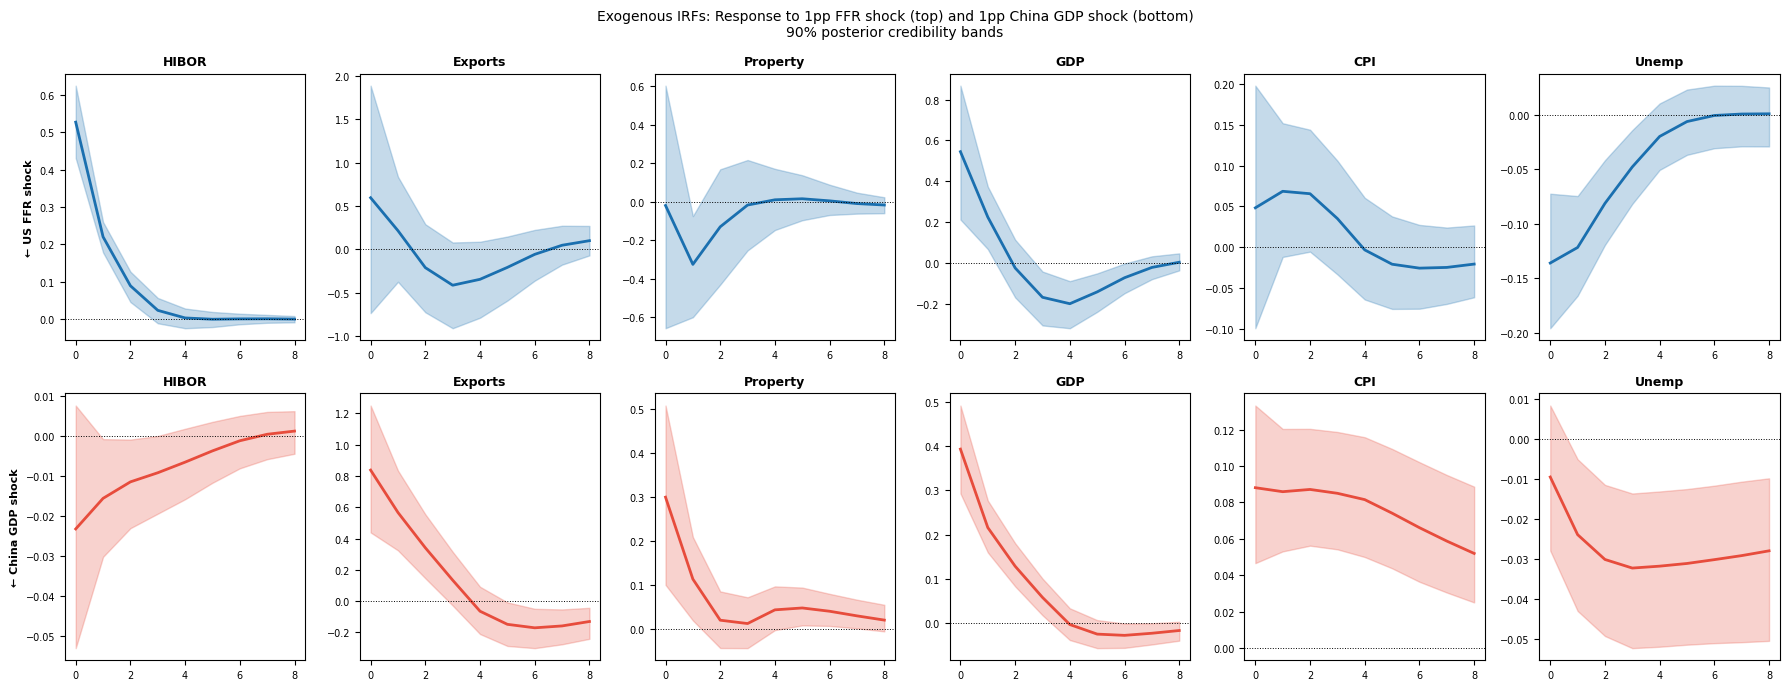

In [5]:
# Exogenous IRF plot: all 6 endogenous responses to FFR and China GDP, h=0..8
horizons = np.arange(9)
exog_labels = ['US FFR', 'China GDP']
endog_labels = ['HIBOR', 'Exports', 'Property', 'GDP', 'CPI', 'Unemp']
colors = ['#1a6faf', '#e74c3c']

fig, axes = plt.subplots(2, 6, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor('white')

for exog_i, (exog_label, color) in enumerate(zip(exog_labels, colors)):
    for endog_i, endog_label in enumerate(endog_labels):
        ax = axes[exog_i, endog_i]
        med = exo_irf_can[endog_i, exog_i, :, 0]
        lo  = exo_irf_can[endog_i, exog_i, :, 1]
        hi  = exo_irf_can[endog_i, exog_i, :, 2]
        ax.fill_between(horizons, lo, hi, alpha=0.25, color=color)
        ax.plot(horizons, med, color=color, lw=2)
        ax.axhline(0, color='black', lw=0.7, ls=':')
        ax.set_title(endog_label, fontsize=9, fontweight='bold')
        ax.set_xticks([0, 2, 4, 6, 8])
        ax.tick_params(labelsize=7)
        if endog_i == 0:
            ax.set_ylabel(f'← {exog_label} shock', fontsize=8, fontweight='bold')

fig.suptitle('Exogenous IRFs: Response to 1pp FFR shock (top) and 1pp China GDP shock (bottom)\n90% posterior credibility bands', fontsize=10)
plt.tight_layout()
plt.savefig('output/exo_irf_all_responses.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

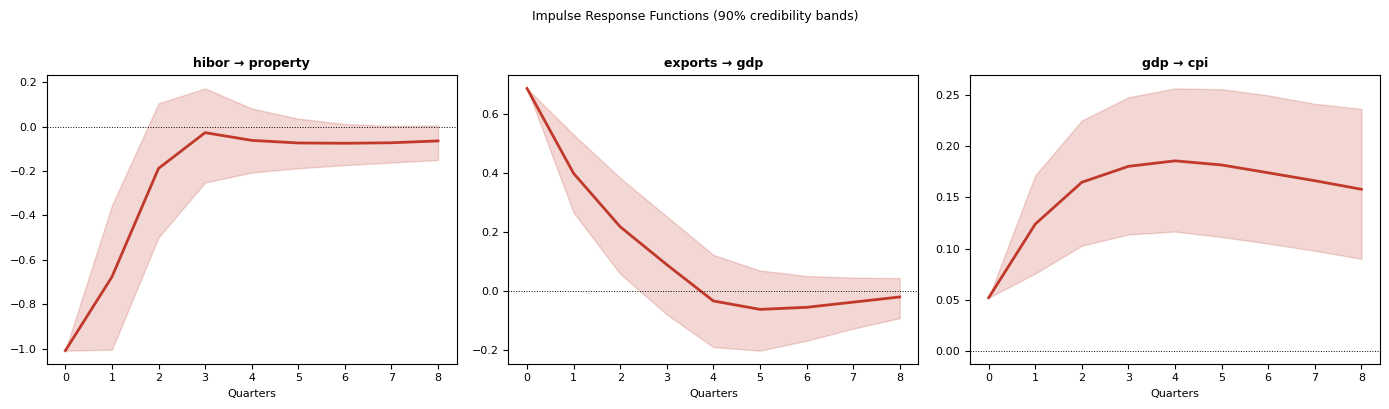

In [6]:
BLUE = '#1a6faf'; RED = '#c0392b'; t = np.arange(9)
fig, axes = plt.subplots(1, 3, figsize=(14, 4)); fig.patch.set_facecolor('white')
for ax, (imp, resp, title) in zip(axes, channels):
    ax.plot(t, irf_can[resp, imp, :, 0], color=RED, lw=2)
    ax.fill_between(t, irf_can[resp, imp, :, 1], irf_can[resp, imp, :, 2], alpha=0.2, color=RED)
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Quarters', fontsize=8); ax.tick_params(labelsize=8)
fig.suptitle('Impulse Response Functions (90% credibility bands)', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('output/phase9a_canonical_irf.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

In [7]:
## FEVD plot
labels_short = ['HIBOR','Exports','Property','GDP','CPI','Unemp']
colors = ['#1a6faf','#e74c3c','#27ae60','#f39c12','#8e44ad','#16a085']
hs = [1, 2, 4, 8]
focus = [(idx['hk_property_price_qoq'],'Property'), (idx['gdp_growth'],'GDP'), (idx['hibor_3m'],'HIBOR')]
fig, axes = plt.subplots(1, 3, figsize=(14, 4)); fig.patch.set_facecolor('white')
for ax_i, (ri, rname) in enumerate(focus):
    data = np.array([fevd_can[ri, :, h-1, 0]*100 for h in hs])
    bottom = np.zeros(len(hs))
    for ci, (color, sl) in enumerate(zip(colors, labels_short)):
        ax = axes[ax_i]
        ax.bar(range(len(hs)), data[:, ci], bottom=bottom, color=color, label=sl, width=0.6)
        for hi, (val, bot) in enumerate(zip(data[:, ci], bottom)):
            if val > 8: ax.text(hi, bot+val/2, f"{val:.0f}%", ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        bottom += data[:, ci]
    ax.set_title(rname, fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(hs))); ax.set_xticklabels([f'h={h}' for h in hs])
    ax.set_ylim(0, 108); ax.tick_params(labelsize=8)
    if ax_i == 2: ax.legend(loc='upper left', fontsize=7, framealpha=0.8)
fig.suptitle('Forecast Error Variance Decomposition (h = 1, 2, 4, 8)', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('output/phase9a_canonical_fevd.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

## 2. GDP Channel Decomposition

**Core finding — speed asymmetry within Channel 1:**
- `hibor → property`: significant at h=1 only (fast, short-lived)
- `property → GDP`: significant at h=1 and h=2 (property amplifies into GDP)
- `hibor → GDP` direct: significant at h=1, h=2, h=4 (credit/mortgage channel, sustained)

**Cholesky order:** hibor → exports → property → gdp → cpi → unemployment

**FEVD at h=8:** Property→GDP 20.5% | Exports→GDP 16.6% | HIBOR→GDP 8.7%

**FEVD: orthogonality:**
HIBOR is ordered first in the Cholesky decomposition. This means the 8.7% HIBOR→GDP share already includes both the direct credit/mortgage path and the indirect path through property prices. The 20.5% property→GDP is only the part of property variation that moves for non-HIBOR reasons (demand shocks, speculation). Two separate effects, not double-counting.

The total property-related GDP variance is therefore larger than 20.5% — but the FEVD cannot decompose it further without additional identification assumptions. The LP-IRF results (ordering-free) confirm property→GDP is real regardless of the Cholesky ordering.

In [8]:
hibor_gdp_fevd_h8 = fevd_can[idx['gdp_growth'], idx['hibor_3m'], 7, 0] * 100
prop_gdp_fevd_h8  = fevd_can[idx['gdp_growth'], idx['hk_property_price_qoq'], 7, 0] * 100
exp_gdp_fevd_h8   = fevd_can[idx['gdp_growth'], idx['hk_exports_china_yoy'], 7, 0] * 100

t = np.arange(9)
BLUE = '#1a6faf'; RED = '#c0392b'; GREEN = '#27ae60'
channels_10a = [
    (idx['hk_property_price_qoq'], idx['gdp_growth'], 'property → GDP', BLUE),
    (idx['hibor_3m'],               idx['gdp_growth'], 'HIBOR → GDP',    RED),
    (idx['hk_exports_china_yoy'],   idx['gdp_growth'], 'exports → GDP',  GREEN),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4)); fig.patch.set_facecolor('white')
for ax, (imp, resp, title, col) in zip(axes, channels_10a):
    med = irf_can[resp, imp, :, 0]
    lo  = irf_can[resp, imp, :, 1]
    hi  = irf_can[resp, imp, :, 2]
    ax.plot(t, med, color=col, lw=2)
    ax.fill_between(t, lo, hi, alpha=0.2, color=col)
    ax.axhline(0, color='k', lw=0.7, ls=':')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Quarters', fontsize=8)
    ax.tick_params(labelsize=8)
    for h in [1, 2, 4]:
        lo_h = irf_can[resp, imp, h, 1]; hi_h = irf_can[resp, imp, h, 2]
        marker = 'o' if not (lo_h < 0 < hi_h) else 'x'
        mc     = col if not (lo_h < 0 < hi_h) else 'grey'
        ax.plot(h, irf_can[resp, imp, h, 0], marker, color=mc, ms=6, zorder=5)
fig.suptitle('GDP Channel Decomposition — IRFs to key shocks (90% credibility bands)', fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig('output/phase10a_gdp_channels.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

fevd_df = pd.DataFrame({
    'channel': ['property→gdp', 'exports→gdp', 'hibor→gdp'],
    'fevd_h8_pct': [prop_gdp_fevd_h8, exp_gdp_fevd_h8, hibor_gdp_fevd_h8]
})
fevd_df.to_csv('output/fevd_gdp_h8.csv', index=False)
display(fevd_df)


,channel,fevd_h8_pct
0,property→gdp,20.491423
1,exports→gdp,16.618343
2,hibor→gdp,8.717539


## 3. Structural Stability

Chow tests (mean: Welch t | variance: Levene) on BVAR(4) residuals. 0 breaks = model absorbed the event.

**Cholesky order:** hibor → exports → property → gdp → cpi → unemployment

| Equation | SARS 2003Q2 | China 2015Q3 | GFC 2008Q3 | COVID 2020Q1 |
|---|---|---|---|---|
| hibor | stable | stable | stable / **var shift** (p=0.035) | stable |
| exports | stable | stable | stable / **var shift** (p=0.003) | borderline (p=0.076) / **var shift** (p=0.029) |
| property | stable | stable | stable | stable |
| gdp | stable | stable | stable (p=0.144) | stable (p=0.278) |
| cpi | stable | stable | stable | **mean break** (p=0.033) |
| unemployment | stable | stable | stable | stable / **var shift** (p=0.003) |

**Bai-Perron (PELT blind search): 0 breaks in all 6 equations.**

The strong result: SARS and China 2015 leave zero trace in the residuals. GFC and COVID show variance shifts only — the shock magnitudes changed, not the transmission mechanism. The single mean break (CPI at COVID) is the honest limitation.

This corroborates the 18/18 OOS result: a structurally stable model forecasts well out of sample because the same transmission architecture holds across all regimes.

In [9]:
# Chow tests on BVAR(4) residuals: mean break (Welch t) + variance shift (Levene)
bvar_canonical.insample_fit()
resid = bvar_canonical.residual_estimates[:, :, 0]
T_eff = resid.shape[0]
dates = df.index[LAGS:]
resid_df = pd.DataFrame(resid, index=dates, columns=ENDOG)
print(f'Residuals: T_eff={T_eff}, {dates[0].date()} to {dates[-1].date()}')

def chow_test(series, break_date, dates):
    pre  = series[dates < pd.Timestamp(break_date)]
    post = series[dates >= pd.Timestamp(break_date)]
    if min(len(pre), len(post)) < 5: return np.nan, np.nan, np.nan, np.nan
    t_stat, t_p   = stats.ttest_ind(pre, post, equal_var=False)
    lev_stat, l_p = stats.levene(pre, post)
    return t_stat, t_p, lev_stat, l_p

breakpoints = [('SARS 2003Q2', '2003-04-01'), ('China 2015Q3', '2015-07-01'), ('GFC 2008Q3', '2008-07-01'), ('COVID 2020Q1', '2020-01-01')]
print('\nChow Tests on BVAR(4) Residuals:')
print(f'{"Equation":<32} {"Break":>14}  {"Mean p":>8}  {"Mean verdict":>14}  {"Var p":>8}  {"Var verdict":>12}')
print('-' * 96)
for col in ENDOG:
    for bp_label, bp_date in breakpoints:
        t_s, t_p, l_s, l_p = chow_test(resid_df[col].values, bp_date, dates)
        if np.isnan(t_p):
            print(f'{col:<32} {bp_label:>14}  {"n/a":>8}  {"n/a":>14}  {"n/a":>8}')
            continue
        m_v = 'BREAK' if t_p < 0.05 else ('borderline' if t_p < 0.10 else 'stable')
        v_v = 'var shift' if l_p < 0.05 else 'stable'
        print(f'{col:<32} {bp_label:>14}  {t_p:>8.4f}  {m_v:>14}  {l_p:>8.4f}  {v_v:>12}')
    print()

Residuals: T_eff=109, 1999-01-01 to 2026-01-01

Chow Tests on BVAR(4) Residuals:
Equation                                  Break    Mean p    Mean verdict     Var p   Var verdict
------------------------------------------------------------------------------------------------
hibor_3m                            SARS 2003Q2    0.1359          stable    0.5649        stable
hibor_3m                           China 2015Q3    0.4122          stable    0.8372        stable
hibor_3m                             GFC 2008Q3    0.9805          stable    0.0353     var shift
hibor_3m                           COVID 2020Q1    0.3082          stable    0.1249        stable

hk_exports_china_yoy                SARS 2003Q2    0.3625          stable    0.2289        stable
hk_exports_china_yoy               China 2015Q3    0.1338          stable    0.2286        stable
hk_exports_china_yoy                 GFC 2008Q3    0.1238          stable    0.0031     var shift
hk_exports_china_yoy               CO

### BP test: Not specifying break time

In [10]:
# Bai-Perron on BVAR(4) residuals — blind search via ruptures PELT
import ruptures as rpt
assert len(dates) == len(resid_df), f'dates/resid mismatch: {len(dates)} vs {len(resid_df)}'

print('Bai-Perron (PELT, BIC-scaled penalty):')
print(f'{"Equation":<32} {"N breaks":>8}  Break dates')
print('-' * 75)

fig, axes = plt.subplots(2, 3, figsize=(15, 8)); fig.patch.set_facecolor('white')
for ax, col in zip(axes.flat, ENDOG):
    signal = resid_df[col].values.reshape(-1, 1)
    n      = len(signal)
    sigma  = signal.std()  # full-series std; conservative (upward-biased if breaks present)
    pen    = sigma**2 * np.log(n) * 3  # 3x BIC: conservative against over-segmentation
    breaks_idx = [b for b in rpt.Pelt(model='l2', min_size=8, jump=1).fit(signal).predict(pen=pen) if b < n]
    break_strs = [dates[b - 1].strftime('%Y-%m') for b in breaks_idx] if breaks_idx else ['none']
    print(f'{col:<32} {len(breaks_idx):>8}  {", ".join(break_strs)}')
    ax.plot(dates, resid_df[col].values, color='#333333', lw=0.8, alpha=0.8)
    for b_idx in breaks_idx:
        ax.axvline(dates[b_idx - 1], color='red', lw=1.5, ls='--', alpha=0.8)
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_title(f'{col}  (breaks: {len(breaks_idx)})', fontsize=8, fontweight='bold')
    ax.tick_params(labelsize=7)

plt.suptitle('Bai-Perron on BVAR(4) Residuals (PELT, BIC penalty) — 0 breaks in all variables', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig('output/phase9b_bai_perron_gdp_cpi.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

Bai-Perron (PELT, BIC-scaled penalty):
Equation                         N breaks  Break dates
---------------------------------------------------------------------------
hibor_3m                                0  none
hk_exports_china_yoy                    0  none
hk_property_price_qoq                   0  none
gdp_growth                              0  none


cpi_inflation                           0  none
unemployment                            0  none


## 4. Local Projection Robustness (Jordà 2005)

HAC-robust LP-IRFs for 4 channels. Contemporaneous controls follow the Cholesky ordering — variables ordered before the shock variable are conditioned on at each horizon. This is an ordering-based conditioning device, not exact structural identification.

**Verdict:** 3/4 channels confirmed independently. Exports→GDP borderline (direction correct, LP loses efficiency vs BVAR). HIBOR→GDP confirmed at h=1, h=2, and h=3 — confirms persistence through 3 quarters.

**h=4 LP/BVAR divergence (HIBOR→GDP):** LP coefficient reverses sign at h=4. LP power decreases at long horizons (fewer observations, wider HAC CI). BVAR remains significant at h=4 via Minnesota prior shrinkage. Paper reports BVAR h=4 and notes LP non-confirmation.


In [11]:
# Local Projection Robustness: Jordà (2005), HAC SEs
irf_bvar = irf_can

endog_arr = df[ENDOG].values.astype(float)
T         = len(df)
H_MAX     = 8
Z_90      = 1.645

def run_lp(shock_var, resp_var):
    shock_i     = idx[shock_var]
    resp_i      = idx[resp_var]
    k           = ENDOG.index(shock_var)
    contemp_idx = [idx[ENDOG[j]] for j in range(k)]
    exog_arr_lp = df[EXOG].values.astype(float)
    betas, lo_arr, hi_arr = [], [], []
    for h in range(H_MAX + 1):
        t_start = LAGS
        t_end   = T - h
        n       = t_end - t_start
        y          = endog_arr[t_start + h : t_end + h, resp_i]
        shock      = endog_arr[t_start:t_end, shock_i]
        ctrl_endog = np.hstack([endog_arr[t_start - lag : t_end - lag, :]
                                for lag in range(1, LAGS + 1)])
        ctrl_exog  = np.hstack([exog_arr_lp[t_start - lag : t_end - lag, :]
                                for lag in range(1, LAGS + 1)])
        parts = [np.ones((n, 1)), shock.reshape(-1, 1)]
        if contemp_idx:
            parts.append(endog_arr[t_start:t_end, contemp_idx].reshape(n, -1))
        parts.extend([ctrl_endog, ctrl_exog])
        X_lp = np.hstack(parts)
        bw   = max(h + 1, int(n ** (1/3)))
        res  = OLS(y, X_lp).fit(cov_type='HAC',
                                 cov_kwds={'maxlags': bw, 'use_correction': True})
        b  = res.params[1]
        se = res.bse[1]
        betas.append(b)
        lo_arr.append(b - Z_90 * se)
        hi_arr.append(b + Z_90 * se)
    return np.array(betas), np.array(lo_arr), np.array(hi_arr)

lp_channels = [
    ('hibor_3m',              'hk_property_price_qoq', 'HIBOR → Property', '#1a6faf'),
    ('hibor_3m',              'gdp_growth',             'HIBOR → GDP',      '#e74c3c'),
    ('hk_exports_china_yoy',  'gdp_growth',             'Exports → GDP',    '#27ae60'),
    ('hk_property_price_qoq', 'gdp_growth',             'Property → GDP',   '#f39c12'),
]

results = {}
for shock_var, resp_var, label, _ in lp_channels:
    betas, lo_arr, hi_arr = run_lp(shock_var, resp_var)
    results[label] = (betas, lo_arr, hi_arr)

rows = []
for shock_var, resp_var, label, _ in lp_channels:
    betas, lo_arr, hi_arr = results[label]
    imp_i  = idx[shock_var]; resp_i = idx[resp_var]
    for h in [1, 2, 3, 4]:
        lp_sig   = 'sig' if lo_arr[h] * hi_arr[h] > 0 else 'x0'
        bvar_sig = 'sig' if irf_bvar[resp_i, imp_i, h, 1] * irf_bvar[resp_i, imp_i, h, 2] > 0 else 'x0'
        rows.append({'Channel': label, 'h': h,
                     'LP β': round(betas[h], 3),
                     'LP lo': round(lo_arr[h], 3),
                     'LP hi': round(hi_arr[h], 3),
                     'LP sig': lp_sig, 'BVAR sig': bvar_sig})
display(pd.DataFrame(rows))


,Channel,h,LP β,LP lo,LP hi,LP sig,BVAR sig
0,HIBOR → Property,1,-3.194,-4.828,-1.560,sig,sig
1,HIBOR → Property,2,-0.908,-2.586,0.769,x0,x0
2,HIBOR → Property,3,0.771,-0.937,2.480,x0,x0
3,HIBOR → Property,4,-0.303,-1.618,1.012,x0,x0
4,HIBOR → GDP,1,-1.068,-1.972,-0.163,sig,sig
5,HIBOR → GDP,2,-1.466,-2.287,-0.645,sig,sig
6,HIBOR → GDP,3,-1.333,-2.354,-0.311,sig,sig
7,HIBOR → GDP,4,0.300,-0.730,1.331,x0,sig
8,Exports → GDP,1,0.049,-0.005,0.102,x0,sig
9,Exports → GDP,2,0.045,-0.013,0.102,x0,sig


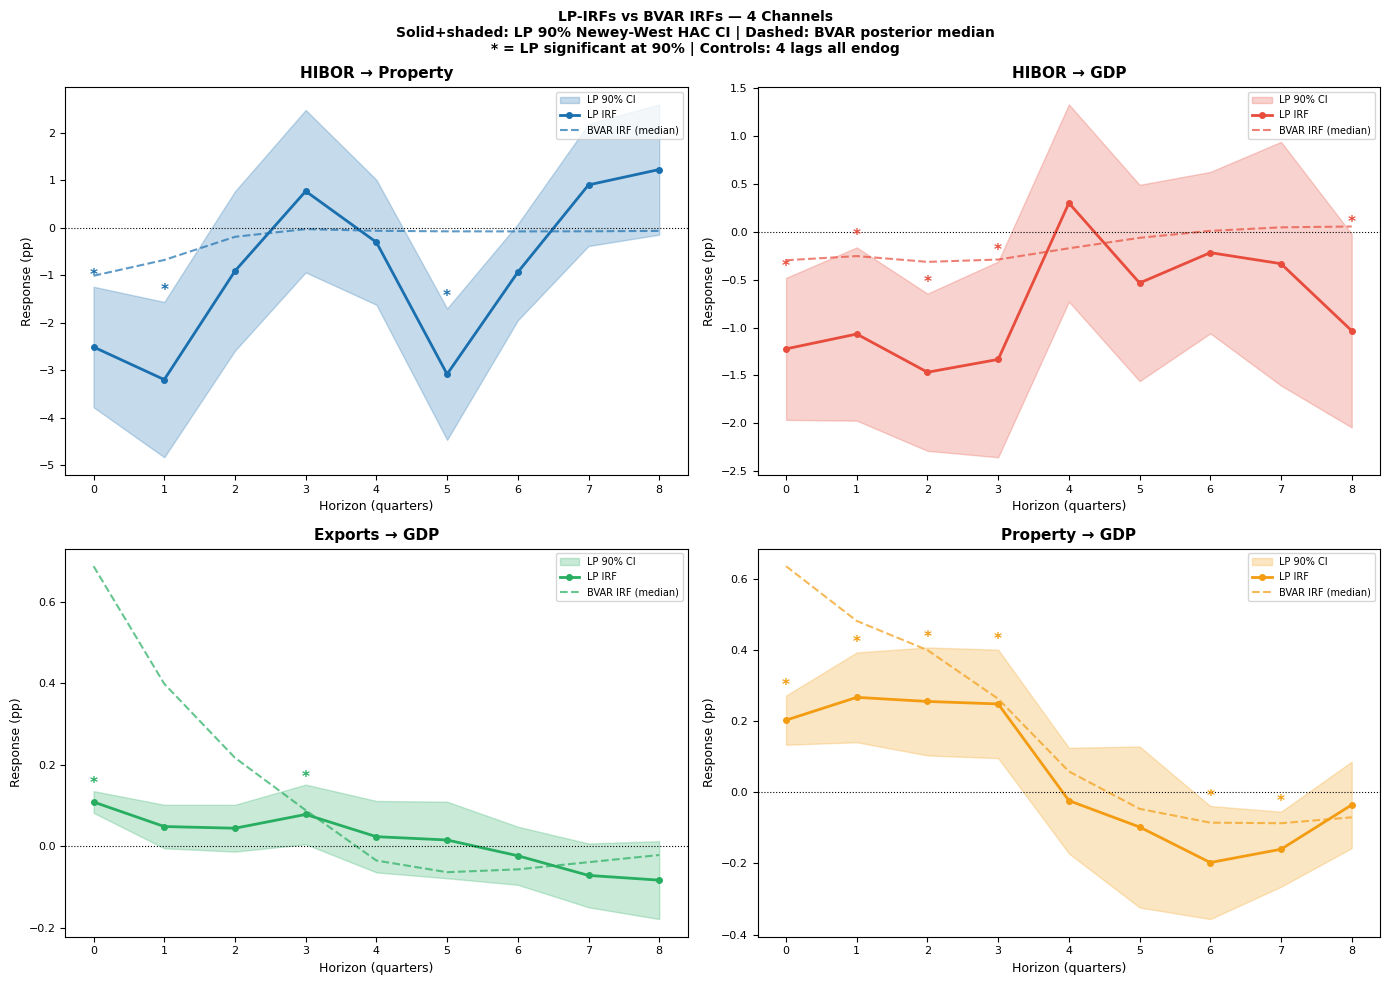

Saved: output/phase10b_lp_irf_4panel.png


In [12]:
# LP-IRF 4-panel figure
horizons = np.arange(H_MAX + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for ax, (shock_var, resp_var, label, color) in zip(axes, lp_channels):
    betas, lo_arr, hi_arr = results[label]
    imp_i  = idx[shock_var]
    resp_i = idx[resp_var]

    ax.fill_between(horizons, lo_arr, hi_arr, alpha=0.25, color=color, label='LP 90% CI')
    ax.plot(horizons, betas, color=color, lw=2, marker='o', ms=4, label='LP IRF')
    ax.plot(horizons, irf_bvar[resp_i, imp_i, :, 0],
            color=color, lw=1.5, ls='--', alpha=0.7, label='BVAR IRF (median)')

    for h in range(H_MAX + 1):
        if lo_arr[h] * hi_arr[h] > 0:
            ypos = hi_arr[h] + 0.02 * (hi_arr.max() - lo_arr.min())
            ax.annotate('*', (h, ypos), ha='center', fontsize=11, color=color, fontweight='bold')

    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Horizon (quarters)', fontsize=9)
    ax.set_ylabel('Response (pp)', fontsize=9)
    ax.set_xticks(horizons)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    'LP-IRFs vs BVAR IRFs — 4 Channels\n'
    'Solid+shaded: LP 90% Newey-West HAC CI | Dashed: BVAR posterior median\n'
    '* = LP significant at 90% | Controls: 4 lags all endog',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()

plt.savefig('output/phase10b_lp_irf_4panel.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print('Saved: output/phase10b_lp_irf_4panel.png')

## 5. ZLB Asymmetry (Exploratory)

Threshold LP-IRF. ZIRP = us_ffr < 0.25%. ZIRP obs: 36/113 (2009 Q1 – 2022 Q1).

| Regime | β (h=1) | 90% CI | Significant? |
|---|---|---|---|
| Normal (FFR ≥ 0.25%) | −2.686 | (−3.796, −1.576) | Yes |
| ZIRP (FFR < 0.25%) | −0.514 | (−7.913, +6.884) | No |

Directionally consistent with impaired transmission at ZLB. Imprecisely estimated (n=36).

In [13]:
# Section 5 — ZLB setup
ZIRP_THRESHOLD = 0.25
zirp = (df['us_ffr'] < ZIRP_THRESHOLD).astype(float).values
endog_arr = df[ENDOG].values.astype(float)
T = len(df)

zirp_dates = df.index[df['us_ffr'] < ZIRP_THRESHOLD]
print(f"ZIRP obs: {int(zirp.sum())} / {T}  ({zirp.mean()*100:.1f}%)")
if len(zirp_dates):
    print(f"First: {zirp_dates[0].strftime('%Y-%m')}  Last: {zirp_dates[-1].strftime('%Y-%m')}")


ZIRP obs: 36 / 113  (31.9%)
First: 2009-01  Last: 2022-01


In [14]:
# Section 5 — threshold LP-IRF estimation
H_MAX = 8
Z_90  = 1.645
resp_i  = ENDOG.index('hk_property_price_qoq')
shock_i = ENDOG.index('hibor_3m')

beta_norm = np.zeros(H_MAX + 1)
beta_zirp = np.zeros(H_MAX + 1)
se_norm   = np.zeros(H_MAX + 1)
se_zirp   = np.zeros(H_MAX + 1)

for h in range(H_MAX + 1):
    t_start = LAGS
    t_end   = T - h
    n_obs   = t_end - t_start

    y      = endog_arr[t_start + h : t_end + h, resp_i]
    shock  = endog_arr[t_start:t_end, shock_i]
    zirp_t = zirp[t_start:t_end]
    norm_t = 1.0 - zirp_t

    regime_cols = np.column_stack([
        norm_t,           # α^norm intercept
        zirp_t,           # α^ZIRP intercept
        shock * norm_t,   # β^norm
        shock * zirp_t,   # β^ZIRP
    ])
    controls = np.hstack([endog_arr[t_start - lag : t_end - lag, :]
                          for lag in range(1, LAGS + 1)])
    X = np.hstack([regime_cols, controls])
    bw  = max(h + 1, int(n_obs ** (1/3)))
    res = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': bw, 'use_correction': True})
    beta_norm[h] = res.params[2]
    beta_zirp[h] = res.params[3]
    se_norm[h]   = res.bse[2]
    se_zirp[h]   = res.bse[3]

rows_zlb = []
for h in range(H_MAX + 1):
    lo_n = beta_norm[h] - Z_90*se_norm[h]; hi_n = beta_norm[h] + Z_90*se_norm[h]
    lo_z = beta_zirp[h] - Z_90*se_zirp[h]; hi_z = beta_zirp[h] + Z_90*se_zirp[h]
    rows_zlb.append({'h': h,
                     'β normal': round(beta_norm[h], 3),
                     'CI normal': f'({lo_n:+.3f}, {hi_n:+.3f})',
                     'sig normal': 'sig' if lo_n*hi_n > 0 else 'x0',
                     'β ZIRP': round(beta_zirp[h], 3),
                     'CI ZIRP': f'({lo_z:+.3f}, {hi_z:+.3f})',
                     'sig ZIRP': 'sig' if lo_z*hi_z > 0 else 'x0'})
display(pd.DataFrame(rows_zlb))


,h,β normal,CI normal,sig normal,β ZIRP,CI ZIRP,sig ZIRP
0,0,-2.090,"(-3.532, -0.649)",sig,-1.022,"(-7.893, +5.850)",x0
1,1,-2.686,"(-3.796, -1.576)",sig,-0.514,"(-7.913, +6.884)",x0
2,2,-0.961,"(-2.370, +0.447)",x0,0.360,"(-9.150, +9.871)",x0
3,3,0.099,"(-1.947, +2.145)",x0,0.310,"(-8.158, +8.779)",x0
4,4,-0.663,"(-2.480, +1.155)",x0,1.965,"(-7.151, +11.082)",x0
5,5,-2.855,"(-3.761, -1.948)",sig,-3.582,"(-12.587, +5.423)",x0
6,6,-2.016,"(-3.174, -0.858)",sig,-5.177,"(-10.970, +0.616)",x0
7,7,-1.309,"(-2.031, -0.587)",sig,-4.887,"(-9.979, +0.204)",x0
8,8,-0.963,"(-1.798, -0.127)",sig,-2.465,"(-8.196, +3.266)",x0


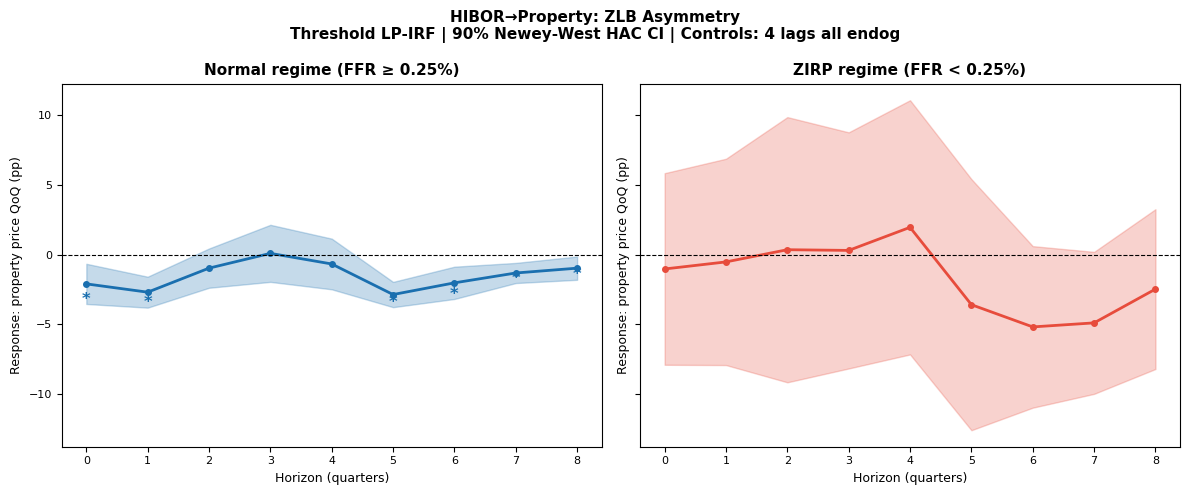

Saved: output/phase9c_zlb_asymmetry.png


In [15]:
# Section 5 — ZLB asymmetry plot
horizons = np.arange(H_MAX + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.patch.set_facecolor('white')

for ax, beta, se, label, color in zip(
    axes,
    [beta_norm, beta_zirp],
    [se_norm,   se_zirp],
    ['Normal regime (FFR ≥ 0.25%)', 'ZIRP regime (FFR < 0.25%)'],
    ['#1a6faf',                      '#e74c3c'],
):
    lo = beta - Z_90 * se
    hi = beta + Z_90 * se
    ax.fill_between(horizons, lo, hi, alpha=0.25, color=color)
    ax.plot(horizons, beta, color=color, lw=2, marker='o', ms=4)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for h in range(H_MAX + 1):
        if lo[h] * hi[h] > 0:
            ax.annotate('*', (h, max(abs(hi[h]), abs(lo[h])) * np.sign(beta[h]) + 0.03),
                        ha='center', fontsize=12, color=color, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Horizon (quarters)', fontsize=9)
    ax.set_ylabel('Response: property price QoQ (pp)', fontsize=9)
    ax.set_xticks(horizons)
    ax.tick_params(labelsize=8)

fig.suptitle(
    'HIBOR→Property: ZLB Asymmetry\n'
    'Threshold LP-IRF | 90% Newey-West HAC CI | Controls: 4 lags all endog',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('output/phase9c_zlb_asymmetry.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

plt.close()
print('Saved: output/phase9c_zlb_asymmetry.png')


## 6. Full 6×6 FEVD at Multiple Horizons

Full variance decomposition for all 6 endogenous variables at h=1, h=4, h=8.

**Why:** Speed asymmetry argument requires showing how FEVD shares shift across horizons.
Shows CPI and unemployment (omitting them signals instability to reviewers).

**Key numbers at h=8:**
- Property→GDP: ~20% (dominant GDP driver)
- Exports→GDP: ~16%
- HIBOR→GDP: ~8% (direct only)
- HIBOR→Property: ~11%

**Note on ~54% unexplained GDP variance:** Property + Exports + HIBOR direct = ~45%. The remaining ~54% is GDP own-shock plus idiosyncratic variation (fiscal policy, domestic demand, external shocks outside this system). This is normal for a 6-variable quarterly VAR — must be acknowledged in paper.

In [16]:
# Full 6×6 FEVD at h=1, h=4, h=8
# Uses fevd_can from Cell 6 — no re-estimation needed

LABELS = ['HIBOR', 'Exports', 'Property', 'GDP', 'CPI', 'Unemp']
H_SHOW = [('h=1', 0), ('h=4', 3), ('h=8', 7)]

for h_label, h_idx in H_SHOW:
    mat = fevd_can[:, :, h_idx, 0] * 100
    df_fevd = pd.DataFrame(mat.round(1),
                            index=pd.Index(LABELS, name='Response ↓'),
                            columns=pd.Index(LABELS, name='Shock →'))
    print(f'\nFEVD at {h_label}  (posterior median, % of forecast error variance)')
    print(df_fevd.to_string())
    row_sums = mat.sum(axis=1)
    print(f'  Row sums (should ≈ 100): {row_sums.round(1).tolist()}')

print('\n\nGDP variance decomposition across horizons:')
print(f'{"Shock":<12}', end='')
for h_label, _ in H_SHOW:
    print(f'  {h_label:>6}', end='')
print()
print('-' * 35)
for j, shock_label in enumerate(LABELS):
    print(f'{shock_label:<12}', end='')
    for _, h_idx in H_SHOW:
        val = fevd_can[idx['gdp_growth'], j, h_idx, 0] * 100
        print(f'  {val:>6.1f}', end='')
    print()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax, (h_label, h_idx) in zip(axes, H_SHOW):
    mat = fevd_can[:, :, h_idx, 0] * 100
    im  = ax.imshow(mat, vmin=0, vmax=100, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(6)); ax.set_xticklabels(LABELS, fontsize=8, rotation=45, ha='right')
    ax.set_yticks(range(6)); ax.set_yticklabels(LABELS, fontsize=8)
    ax.set_title(f'FEVD {h_label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Shock →', fontsize=8)
    ax.set_ylabel('Response ↓', fontsize=8)
    for i in range(6):
        for j in range(6):
            val = mat[i, j]
            color = 'white' if val > 45 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.8, label='%')

plt.suptitle(
    'Full 6×6 FEVD at h=1, h=4, h=8 (posterior median)\n'
    'BVAR(4) Minnesota | hibor-first Cholesky | ML-optimal delta',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig('output/full_6x6_fevd.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print('\nSaved: output/full_6x6_fevd.png')


FEVD at h=1  (posterior median, % of forecast error variance)
Shock →     HIBOR  Exports  Property   GDP   CPI  Unemp
Response ↓                                             
HIBOR       100.0      0.0       0.0   0.0   0.0    0.0
Exports       1.1     98.9       0.0   0.0   0.0    0.0
Property     10.0      3.6      86.4   0.0   0.0    0.0
GDP           3.4     18.4      15.7  62.5   0.0    0.0
CPI           1.0      0.6       0.0   0.5  97.8    0.0
Unemp         3.4      0.5       8.1  14.6   0.1   73.3
  Row sums (should ≈ 100): [100.0, 100.0, 100.0, 100.0, 100.0, 100.0]

FEVD at h=4  (posterior median, % of forecast error variance)
Shock →     HIBOR  Exports  Property   GDP   CPI  Unemp
Response ↓                                             
HIBOR        96.6      2.0       0.4   0.3   0.3    0.3
Exports       2.6     95.6       0.4   0.3   0.9    0.2
Property     12.4      3.7      83.1   0.3   0.4    0.2
GDP           8.1     16.6      20.7  53.0   1.2    0.3
CPI           4.1   


Saved: output/full_6x6_fevd.png


## 7. Historical Decomposition of GDP

Decomposes each quarter's GDP deviation from its long-run mean into contributions from each structural shock.

**Main result:** GDP own-shock dominates (38.6% of historical variance) — reflects fiscal, external, and unmodelled domestic shocks. Property shock is the second largest driver (20.9%), exports third (19.0%). HIBOR direct contribution is modest at 11.4%, consistent with it operating through property and credit rather than as a direct GDP shock.

**Crises:** GFC driven by GDP own-shock (−1.70pp avg) and exports collapse (−0.75pp). COVID dominated by GDP own-shock (−3.96pp). HIBOR and property shocks contribute little at crisis quarter — the monetary channel is a slow-moving structural driver, not a crisis amplifier.

**Limitation:** China GDP is exogenous and not visible here — its contribution flows through the exports shock bar.

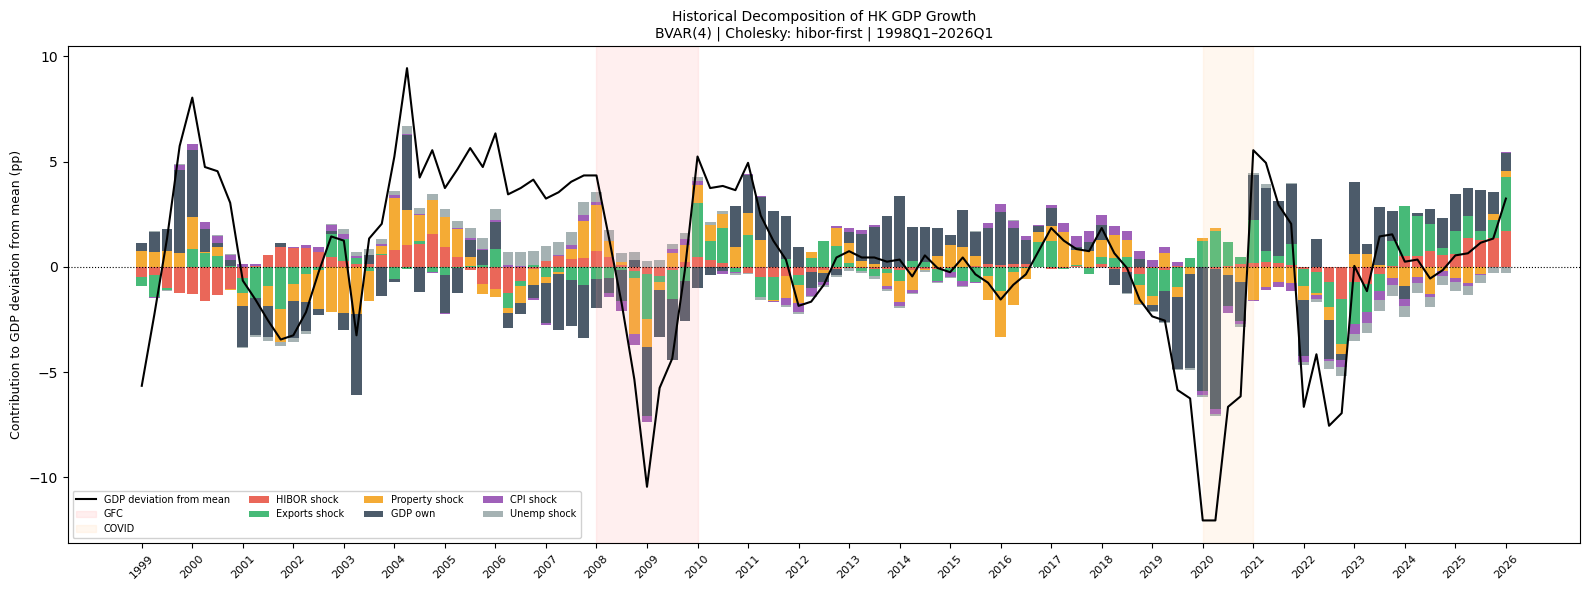

In [17]:
hd = bvar_canonical.historical_decomposition(credibility_level=0.90)
gdp_i    = idx['gdp_growth']
T_hd     = hd.shape[2]
dates_hd = df.index[LAGS : LAGS + T_hd]

SHOCK_LABELS = ['HIBOR shock', 'Exports shock', 'Property shock', 'GDP own', 'CPI shock', 'Unemp shock']
COLORS       = ['#e74c3c', '#27ae60', '#f39c12', '#2c3e50', '#8e44ad', '#95a5a6']

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
bottom_pos = np.zeros(T_hd)
bottom_neg = np.zeros(T_hd)
x = np.arange(T_hd)

for j in range(6):
    contrib = hd[gdp_i, j, :, 0]
    pos = np.where(contrib > 0, contrib, 0)
    neg = np.where(contrib < 0, contrib, 0)
    ax.bar(x, pos, bottom=bottom_pos, color=COLORS[j], alpha=0.85, label=SHOCK_LABELS[j], width=0.85)
    ax.bar(x, neg, bottom=bottom_neg, color=COLORS[j], alpha=0.85, width=0.85)
    bottom_pos += pos
    bottom_neg += neg

gdp_dev = df['gdp_growth'].values[LAGS : LAGS + T_hd] - df['gdp_growth'].mean()
ax.plot(x, gdp_dev, color='black', lw=1.5, zorder=5, label='GDP deviation from mean')
ax.axhline(0, color='black', lw=0.8, ls=':')

for start, end, label, color in [('2008-01-01', '2009-12-31', 'GFC', '#ff9999'),
                                   ('2020-01-01', '2020-12-31', 'COVID', '#ffcc99')]:
    s_i = np.searchsorted(dates_hd, pd.Timestamp(start))
    e_i = np.searchsorted(dates_hd, pd.Timestamp(end))
    if s_i < T_hd:
        ax.axvspan(s_i, min(e_i, T_hd - 1), alpha=0.15, color=color, label=label)

tick_idx = range(0, T_hd, 4)
ax.set_xticks(list(tick_idx))
ax.set_xticklabels([dates_hd[i].strftime('%Y') for i in tick_idx], fontsize=8, rotation=45)
ax.set_ylabel('Contribution to GDP deviation from mean (pp)', fontsize=9)
ax.set_title('Historical Decomposition of HK GDP Growth\nBVAR(4) | Cholesky: hibor-first | 1998Q1–2026Q1', fontsize=10)
ax.legend(loc='lower left', fontsize=7, ncol=4, framealpha=0.9)
plt.tight_layout()
plt.savefig('output/historical_decomp_gdp.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

In [18]:
# Average contribution by shock (full sample)
mean_abs  = np.array([np.abs(hd[gdp_i, j, :, 0]).mean() for j in range(6)])
display(pd.DataFrame({'Shock': SHOCK_LABELS,
                      'Mean |contrib| (pp)': mean_abs.round(3),
                      '% of mean |contrib|': (mean_abs / mean_abs.sum() * 100).round(1)}))

# GFC and COVID episode averages
for ep_label, start, end in [('GFC 2008-2009', '2008-01-01', '2009-12-31'),
                               ('COVID 2020',   '2020-01-01', '2020-12-31')]:
    mask = (dates_hd >= start) & (dates_hd <= end)
    if mask.sum() > 0:
        contribs = [hd[gdp_i, j, mask, 0].mean() for j in range(6)]
        display(pd.DataFrame({'Shock': SHOCK_LABELS,
                              f'{ep_label} avg contrib (pp)': [round(c, 2) for c in contribs]}))

,Shock,Mean |contrib| (pp),% of mean |contrib|
0,HIBOR shock,0.451,11.4
1,Exports shock,0.751,19.0
2,Property shock,0.825,20.9
3,GDP own,1.526,38.6
4,CPI shock,0.192,4.9
5,Unemp shock,0.211,5.3


,Shock,GFC 2008-2009 avg contrib (pp)
0,HIBOR shock,0.05
1,Exports shock,-0.75
2,Property shock,0.02
3,GDP own,-1.70
4,CPI shock,-0.11
5,Unemp shock,0.37


,Shock,COVID 2020 avg contrib (pp)
0,HIBOR shock,0.02
1,Exports shock,1.08
2,Property shock,-0.21
3,GDP own,-3.96
4,CPI shock,-0.23
5,Unemp shock,-0.08
